# Model Training

## Import packages

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

# Modelling
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

## Load and pre-process data

We start by importing the 3 datasets and pre-processing it as described in the `EDA.ipynb` notebook:

In [41]:
drug_synergy_df=pd.read_csv('data/drug_synergy.csv')
print('Drug synergy size: ' + str(drug_synergy_df.shape))

cell_lines_df=pd.read_csv('data/cell_lines.csv')
print('Cell lines dataset size: ' + str(cell_lines_df.shape))

drug_portfolio_df=pd.read_csv('data/drug_portfolio.csv', sep='\t')
print('Drug portfolio dataset size: ' + str(drug_portfolio_df.shape))

Drug synergy size: (3879, 16)
Cell lines dataset size: (159, 10)
Drug portfolio dataset size: (118, 11)


now we do quality control and feature engineering, also according to the `EDA.ipynb` noteebok:

In [42]:
#quality filtering
drug_synergy_df = drug_synergy_df[drug_synergy_df.QA==1]
drug_synergy_df

#missing vals fitlering
drug_synergy_bool = (drug_synergy_df.isna().sum() < len(drug_synergy_df)*0.2).values #logical vector, T if less than 20% missing values
cell_lines_df_bool = (cell_lines_df.isna().sum() < len(cell_lines_df)*0.2).values
drug_portfolio_df_bool = (drug_portfolio_df.isna().sum() < len(drug_portfolio_df)*0.2).values

drug_synergy_df = drug_synergy_df[ drug_synergy_df.columns[drug_synergy_bool] ]
cell_lines_df = cell_lines_df[ cell_lines_df.columns[cell_lines_df_bool] ]
drug_portfolio_df = drug_portfolio_df[ drug_portfolio_df.columns[drug_portfolio_df_bool] ]

#irrelevant features filtering
badfeats = ['Challenge', 'QA', 'COSMIC ID', 'GDSC tissue descriptor 1', 'TCGA','Dataset','Combination ID']

#filter irrelevant features
def filterfunc( df ):
    ''' Takes a df and checks its cols, if they in badfeats, they are removed '''
    tobedropped = []
    for col in df.columns:
        if col in badfeats:
            tobedropped.append(col)
    
    df = df.drop( tobedropped, axis=1 )
    return df

drug_synergy_df = filterfunc(drug_synergy_df)
cell_lines_df = filterfunc(cell_lines_df)
drug_portfolio_df = filterfunc(drug_portfolio_df)

#cell line, drugA and drug B dfs
cell_lines_df = cell_lines_df[ ['Cell line name', 'GDSC tissue descriptor 2', 'MSI', 'Growth properties'] ]
cell_lines_df.drop_duplicates( inplace=True ) #as we removed some columns, we might have duplicate rows

drug_portfolio_df_A = drug_portfolio_df[ ['Challenge drug name', 'Putative target','Function', 'Pathway'] ]
drug_portfolio_df_A.columns = ['Compound A', 'Putative target A','Function A', 'Pathway A'] #rename (notice we use 'Challenge drug name' and not 'Drug name')
drug_portfolio_df_A.drop_duplicates( inplace=True )

drug_portfolio_df_B = drug_portfolio_df[ ['Challenge drug name', 'Putative target','Function', 'Pathway'] ]
drug_portfolio_df_B.columns = ['Compound B', 'Putative target B','Function B', 'Pathway B'] #rename
drug_portfolio_df_B.drop_duplicates( inplace=True )

#join on drug combination df
df = pd.merge( drug_synergy_df, cell_lines_df, on='Cell line name' ) #create df and add cell line info
df = pd.merge( df, drug_portfolio_df_A, on='Compound A' ) #add drug A info
df = pd.merge( df, drug_portfolio_df_B, on='Compound B' ) #add drug B info

print( 'Drug synergy related features:' )
print(*drug_synergy_df.columns, sep=", ")
print( '-----------------------------------------------------------------------------------------------------------------' )

print( 'Cell line related features:' )
print(*cell_lines_df.columns, sep=", ")
print( '-----------------------------------------------------------------------------------------------------------------' )


print( 'Drug related features:' )
print(*drug_portfolio_df_A.columns, sep=", ")
print( '-----------------------------------------------------------------------------------------------------------------' )

print('\n' )
print( 'Final dataframe:' + str(df.shape) )
df.head()

Drug synergy related features:
Cell line name, Compound A, Compound B, Max. conc. A, Max. conc. B, IC50 A, H A, Einf A, IC50 B, H B, Einf B, Synergy score
-----------------------------------------------------------------------------------------------------------------
Cell line related features:
Cell line name, GDSC tissue descriptor 2, MSI, Growth properties
-----------------------------------------------------------------------------------------------------------------
Drug related features:
Compound A, Putative target A, Function A, Pathway A
-----------------------------------------------------------------------------------------------------------------


Final dataframe:(3475, 21)


,Cell line name,Compound A,Compound B,Max. conc. A,Max. conc. B,IC50 A,H A,Einf A,IC50 B,H B,...,Synergy score,GDSC tissue descriptor 2,MSI,Growth properties,Putative target A,Function A,Pathway A,Putative target B,Function B,Pathway B
0,BT-20,AKT,ADAM17,1.0,75.0,1.000000,0.809002,59.122436,9.639714,0.757977,...,29.540390,breast,MSS/MSI-L,Adherent,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration
1,CAL-51,AKT,ADAM17,1.0,75.0,1.000000,0.726984,11.150843,75.000000,0.375043,...,0.315422,breast,MSS/MSI-L,Adherent,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration
2,HCC1187,AKT,ADAM17,1.0,75.0,0.410029,1.496901,51.921265,1.000000,0.000000,...,-0.801993,breast,MSS/MSI-L,Suspension,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration
3,HCC1806,AKT,ADAM17,1.0,75.0,0.313992,10.000000,63.399635,75.000000,0.392570,...,-26.733250,breast,MSS/MSI-L,Adherent,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration
4,HCC1937,AKT,ADAM17,1.0,75.0,1.000000,0.771830,41.529554,1.677924,1.119487,...,32.165520,breast,MSS/MSI-L,Adherent,AKT1;AKT2;AKT3,Oncogenic signal,AKT/PI3K,ADAM17,Differentiation,EMT/migration


## Model creation

We craete a dataframe `X` for the predictor varaibles and another one `y` for the synergy score:

In [43]:
#create dfs for features and output
X = df.drop(['Synergy score'], axis=1) 
y = df['Synergy score']


and split the data for training and testing:

In [44]:
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print( 'Training data: ' + str(X_train.shape) )
print( 'Testing data: ' + str(X_test.shape) )

Training data: (2780, 20)
Testing data: (695, 20)


## Feature transformation

As we are dealing with categorical and numerical variables, we need to process them differently. We use one-hot-encoding for the categorical variables and standarize the numerical ones:

In [47]:
#feature transformation

#identify cat and num vars
catfeats = X.select_dtypes( include="str" ).columns #categorical features
numfeats = X.select_dtypes( include="number" ).columns #numerical features

#define transformation pipeline
cattransformer = OneHotEncoder() #one-hot-encode cat vars
numtransformer = StandardScaler() #normalize num vars

preprocessor = ColumnTransformer( 
    [
        ("OneHotEncoder", cattransformer, catfeats),
         ("StandardScaler", numtransformer, numfeats), 
    ]
) #processes subsets of features differently, then merges them into a single feature space

and we apply it to our training and testing subsets:

In [48]:
#apply transformer to data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.fit_transform(X_test)

print( 'Training data: ' + str(X_train.shape) )
print( 'Testing data: ' + str(X_test.shape) )

Training data: (2780, 333)
Testing data: (695, 324)


### Training and evaluation

Here we use the suggested metric from the paper, weighted Pearson correlation:

$ \rho_w = \dfrac{\sum_{i=1}^N \sqrt{n_i - 1} \rho_i}{\sum_{i=1}^N \sqrt{n_i - 1}{}} $

where:
* $\rho_i$ is the Pearson correlation coeficient between the predicted and experimental synergy scores for drug combination $i$
* $n_i$ is the number of cell lines tested with drug combination $i$
* $N$ is the total number of drug combinations

In [ ]:
import pandas as pd
from scipy.stats import pearsonr

def weighted_pearson_synergy(df, true_col, pred_col, drug_a_col, drug_b_col):
    """
    Computes the weighted Pearson correlation coefficient for drug synergy.
    
    Parameters:
    - df: DataFrame containing true and predicted scores + drug names
    - true_col, pred_col: Strings, column names for scores
    - drug_a_col, drug_b_col: Strings, column names for the drugs
    """
    
    # 1. Group by drug combination (i)
    # Each group represents one combination tested across various cell lines
    grouped = df.groupby([drug_a_col, drug_b_col])
    
    correlations = []
    weights = []
    
    for (drug_a, drug_b), group in grouped:
        # We need at least 2 data points (cell lines) to calculate a correlation
        if len(group) > 1:
            # Calculate Pearson Rho (i)
            rho_i, _ = pearsonr(group[true_col], group[pred_col])
            
            # If rho is NaN (e.g. constant values), we skip or treat as 0
            if not pd.isna(rho_i):
                correlations.append(rho_i)
                weights.append(len(group)) # n_i (number of cell lines)

    # 2. Compute weighted average: Sum(rho_i * n_i) / Sum(n_i)
    if not correlations:
        return 0
        
    weighted_rho = sum(r * n for r, n in zip(correlations, weights)) / sum(weights)
    
    return weighted_rho

# Example Usage:
# score = weighted_pearson_synergy(results_df, 'Synergy score', 'Predicted', 'Compound A', 'Compound B')
# print(f"Weighted Pearson Correlation: {score:.4f}")


In [ ]:
#create evaluation metric function
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [ ]:
#create dicc of modeling methods
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = [] #list of implemented models
r2_list =[] #list of r2 for each model

#apply methods
for i in range( len(list(models)) ):
    #train
    model = list( models.values() )[i]
    model.fit( X_train, y_train )

    #predict
    y_train_pred = model.predict( X_train )
    y_test_pred = model.predict( X_test )
    
    #evaluate both train and test datasets
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model( y_train, y_train_pred )

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model( y_test, y_test_pred )

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 21.8059
- Mean Absolute Error: 15.7549
- R2 Score: 0.3654
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 26.6957
- Mean Absolute Error: 18.4184
- R2 Score: 0.1679


Lasso
Model performance for Training set
- Root Mean Squared Error: 26.7746
- Mean Absolute Error: 19.0690
- R2 Score: 0.0433
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 29.0934
- Mean Absolute Error: 20.2003
- R2 Score: 0.0118


Ridge
Model performance for Training set
- Root Mean Squared Error: 21.8142
- Mean Absolute Error: 15.7394
- R2 Score: 0.3650
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 26.6401
- Mean Absolute Error: 18.3503
- R2 Score: 0.1714


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 20.0875
- Mean Absolute Error: 14.4348
- R2 Score: 0.4615
---------

In [43]:
#summarize results
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2 Score']).sort_values(by=["R2 Score"],ascending=False)

,Model Name,R2 Score
2,Ridge,0.171413
7,CatBoosting Regressor,0.168909
0,Linear Regression,0.167948
6,XGBRegressor,0.167011
5,Random Forest Regressor,0.131035
3,K-Neighbors Regressor,0.120999
8,AdaBoost Regressor,0.045791
1,Lasso,0.011778
4,Decision Tree,-0.379669


## Results

In [44]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 16.79


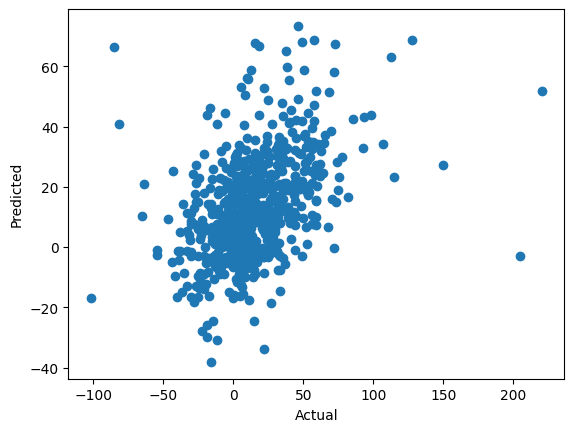

In [45]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

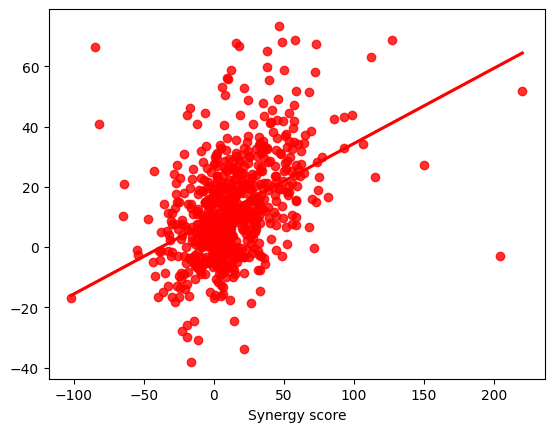

In [46]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [47]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
2789,25.848650,3.322037,22.526613
1424,24.378630,31.982367,-7.603737
309,-19.085140,-25.860618,6.775478
2917,20.951370,20.008214,0.943156
3036,40.200730,7.937672,32.263058
...,...,...,...
1011,-1.447185,10.194975,-11.642160
547,23.230260,9.747301,13.482959
776,58.959930,27.221486,31.738444
2872,3.431602,6.006634,-2.575032
